<a href="https://colab.research.google.com/github/Wasimul2023/Superstore_sales_Analysis/blob/main/Superstore_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import  files
uploaded = files.upload()

Saving SuperStoreOrders.xlsx to SuperStoreOrders (1).xlsx


In [6]:
df = pd.read_excel("SuperStoreOrders.xlsx")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01 00:00:00,2011-06-01 00:00:00,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01 00:00:00,2011-08-01 00:00:00,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01 00:00:00,2011-05-01 00:00:00,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01 00:00:00,2011-05-01 00:00:00,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01 00:00:00,2011-08-01 00:00:00,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [7]:
df.shape

(51290, 21)

In [8]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  int64  
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [10]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [11]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [12]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [13]:
df.describe()

,sales,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
std,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931
min,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [14]:
unique_customers = df['customer_name'].nunique()

print("Number of unique customers:", unique_customers)

Number of unique customers: 795


## 3. Data Cleaning and Preparation

In [15]:
df_clean = df.copy()

In [16]:
from datetime import datetime

def clean_date(value):

    # Case 1: If Excel has already stored the value as a date
    if isinstance(value, (pd.Timestamp, datetime)):
        return pd.Timestamp(
            year=value.year,
            month=value.day,
            day=value.month
        )

    # Case 2: If the value is stored as text such as 13-01-2011
    return pd.to_datetime(
        value,
        format='%d-%m-%Y',
        errors='coerce'
    )


df_clean['order_date'] = df_clean['order_date'].apply(clean_date)
df_clean['ship_date'] = df_clean['ship_date'].apply(clean_date)

In [17]:
print(df_clean[['order_date', 'ship_date']].dtypes)

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


In [18]:
print("First order date:", df_clean['order_date'].min())
print("Last order date:", df_clean['order_date'].max())

print("First ship date:", df_clean['ship_date'].min())
print("Last ship date:", df_clean['ship_date'].max())

First order date: 2011-01-01 00:00:00
Last order date: 2014-12-31 00:00:00
First ship date: 2011-01-03 00:00:00
Last ship date: 2015-01-07 00:00:00


In [19]:
invalid_shipping = (
    df_clean['ship_date'] < df_clean['order_date']
).sum()

print("Ship dates earlier than order dates:", invalid_shipping)

Ship dates earlier than order dates: 0


## 4. Numeric Data Validation and Outlier Investigation

In [20]:
print("Negative sales:", (df_clean['sales'] < 0).sum())

print("Zero sales:", (df_clean['sales'] == 0).sum())

print("Invalid quantity:", (df_clean['quantity'] <= 0).sum())

print(
    "Invalid discount:",
    ((df_clean['discount'] < 0) | (df_clean['discount'] > 1)).sum()
)

print(
    "Negative shipping cost:",
    (df_clean['shipping_cost'] < 0).sum()
)

Negative sales: 0
Zero sales: 1
Invalid quantity: 0
Invalid discount: 0
Negative shipping cost: 0


In [21]:
loss_transactions = (df_clean['profit'] < 0).sum()

loss_percentage = (
    loss_transactions / len(df_clean)
) * 100

print("Loss-making transactions:", loss_transactions)
print("Loss percentage:", round(loss_percentage, 2), "%")

Loss-making transactions: 12543
Loss percentage: 24.46 %


In [22]:
df_clean.loc[
    df_clean['sales'] == 0,
    [
        'order_id',
        'customer_name',
        'product_name',
        'sales',
        'quantity',
        'discount',
        'profit'
    ]
]

,order_id,customer_name,product_name,sales,quantity,discount,profit
40017,US-2014-102288,Zuschuss Carroll,Hoover Replacement Belt for Commercial Guardsm...,0,1,0.8,-1.11


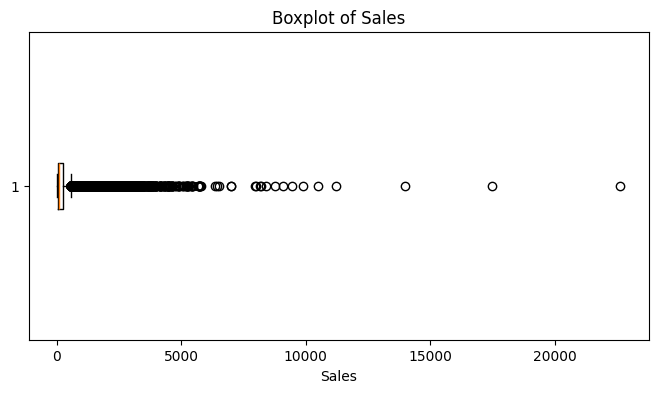

In [23]:
plt.figure(figsize=(8, 4))

plt.boxplot(df_clean['sales'], vert=False)

plt.title('Boxplot of Sales')
plt.xlabel('Sales')

plt.show()

In [24]:
Q1 = df_clean['sales'].quantile(0.25)
Q3 = df_clean['sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = (
    (df_clean['sales'] < lower_bound) |
    (df_clean['sales'] > upper_bound)
).sum()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Potential sales outliers:", sales_outliers)

Q1: 31.0
Q3: 251.0
IQR: 220.0
Lower bound: -299.0
Upper bound: 581.0
Potential sales outliers: 5655


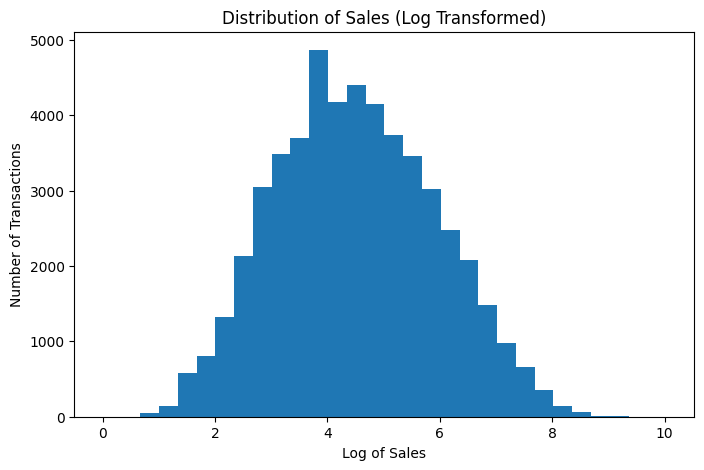

In [25]:
df_clean['log_sales'] = np.log1p(df_clean['sales'])

plt.figure(figsize=(8, 5))

plt.hist(df_clean['log_sales'], bins=30)

plt.title('Distribution of Sales (Log Transformed)')
plt.xlabel('Log of Sales')
plt.ylabel('Number of Transactions')

plt.show()

In [26]:
category_sales = (
    df_clean.groupby('category')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64


In [27]:
yearly_sales = (
    df_clean.groupby('year')['sales']
    .sum()
)

print(yearly_sales)

year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: sales, dtype: int64


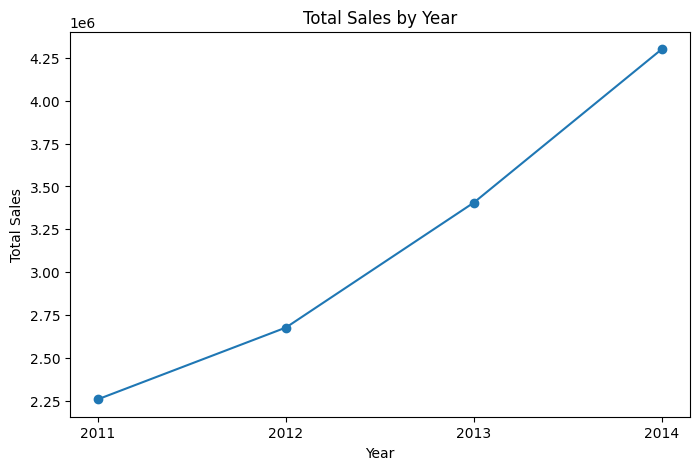

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o'
)

plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_sales.index)

plt.show()

In [29]:
customer_frequency = (
    df_clean.groupby('customer_name')['order_id']
    .nunique()
)

print(customer_frequency.describe())

count    795.000000
mean      32.393711
std        5.407543
min       15.000000
25%       28.000000
50%       32.000000
75%       36.000000
max       47.000000
Name: order_id, dtype: float64


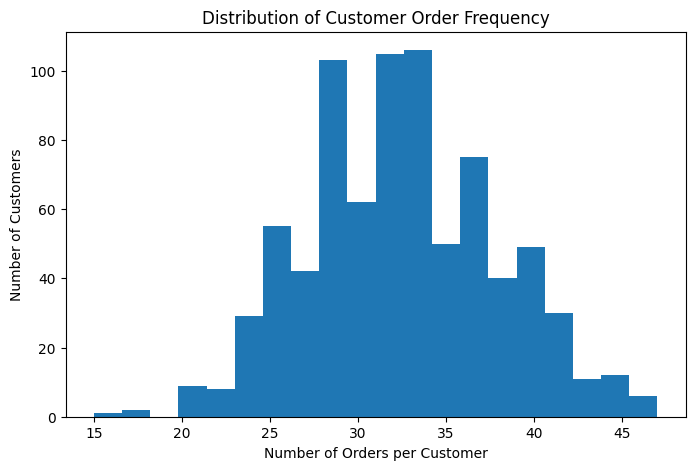

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(customer_frequency, bins=20)

plt.title('Distribution of Customer Order Frequency')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')

plt.show()

In [31]:
top_customers = (
    df_clean.groupby('customer_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

customer_name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: sales, dtype: int64


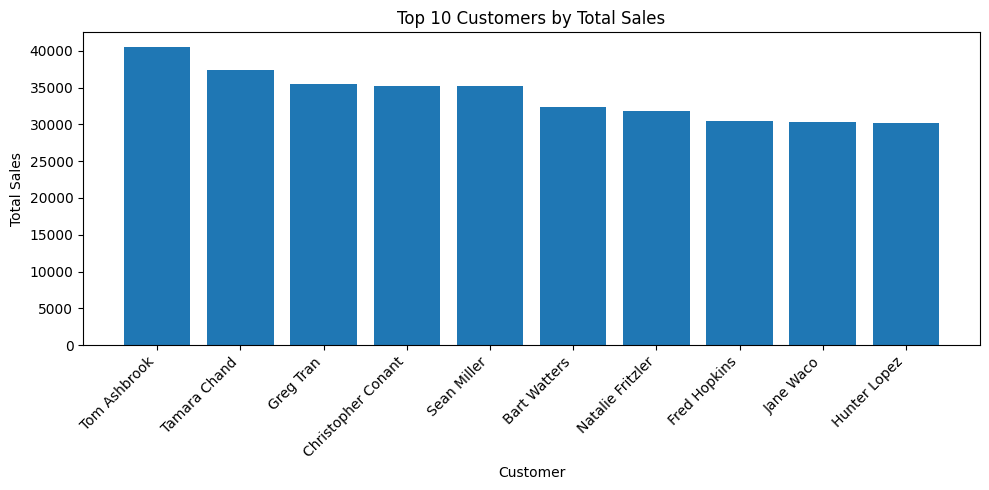

In [32]:
plt.figure(figsize=(10, 5))

plt.bar(top_customers.index, top_customers.values)

plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Customer')
plt.ylabel('Total Sales')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

 6. RFM Feature Engineering

In [33]:
analysis_date = df_clean['order_date'].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2015-01-01 00:00:00


In [34]:
rfm = df_clean.groupby('customer_name').agg(
    Recency=('order_date', lambda x: (analysis_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('sales', 'sum')
).reset_index()

rfm.head()

,customer_name,Recency,Frequency,Monetary
0,Aaron Bergman,17,37,24646
1,Aaron Hawkins,13,34,20759
2,Aaron Smayling,24,31,14207
3,Adam Bellavance,36,41,20189
4,Adam Hart,3,42,21720


In [35]:
rfm.shape

(795, 4)

In [36]:
rfm.head(10)

,customer_name,Recency,Frequency,Monetary
0,Aaron Bergman,17,37,24646
1,Aaron Hawkins,13,34,20759
2,Aaron Smayling,24,31,14207
3,Adam Bellavance,36,41,20189
4,Adam Hart,3,42,21720
5,Adam Shillingsburg,16,36,15445
6,Adrian Barton,28,40,25125
7,Adrian Hane,22,26,11406
8,Adrian Shami,42,24,11287
9,Aimee Bixby,36,28,16205


In [37]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,795.000000,795.000000,795.000000
mean,24.368553,32.393711,15903.025157
std,27.438069,5.407543,5209.800805
min,1.000000,15.000000,3891.000000
25%,7.000000,28.000000,12242.500000
50%,17.000000,32.000000,15258.000000
75%,34.000000,36.000000,18770.500000
max,429.000000,47.000000,40489.000000


## 7. RFM Distribution and Outlier Analysis

In [38]:
rfm_features = ['Recency', 'Frequency', 'Monetary']

print(rfm[rfm_features].skew())

Recency      5.292320
Frequency    0.140497
Monetary     0.849698
dtype: float64


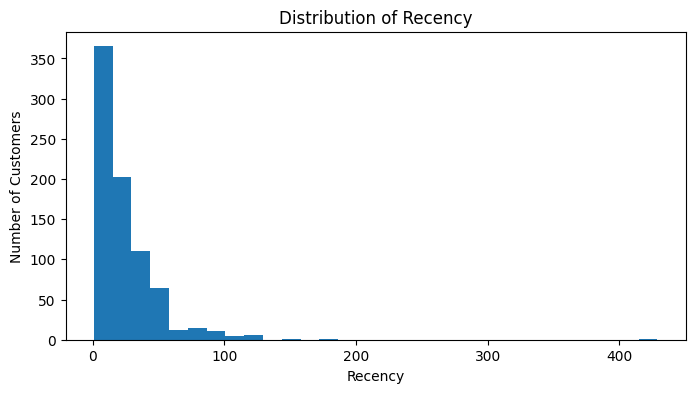

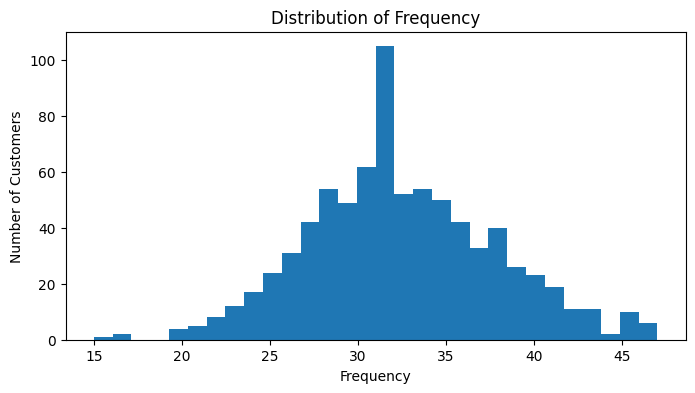

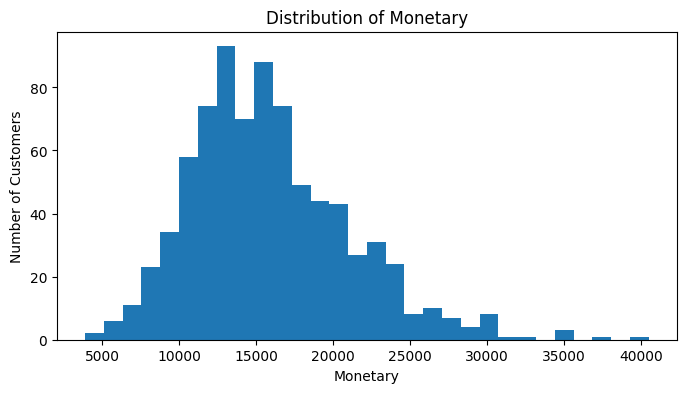

In [39]:
for feature in rfm_features:
    plt.figure(figsize=(8, 4))
    plt.hist(rfm[feature], bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
    plt.show()

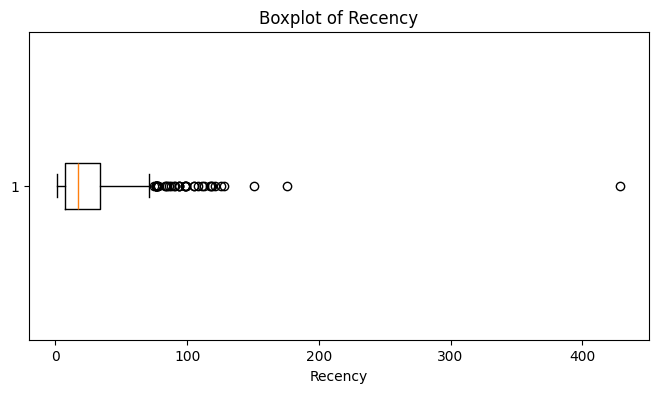

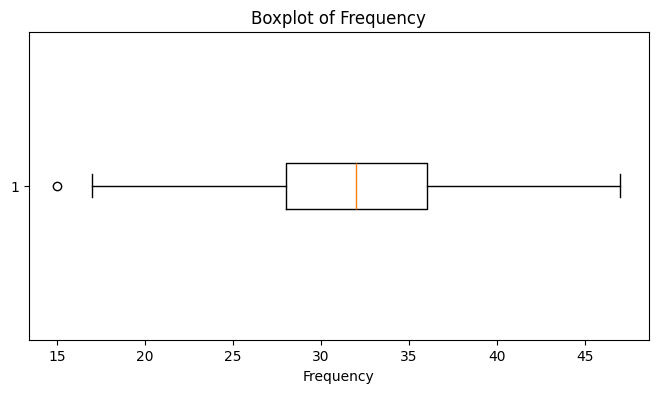

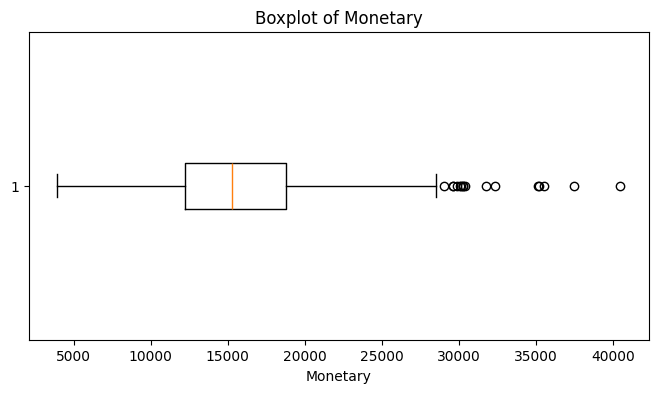

In [40]:
for feature in rfm_features:
    plt.figure(figsize=(8, 4))
    plt.boxplot(rfm[feature], vert=False)
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()

In [41]:
for feature in rfm_features:

    Q1 = rfm[feature].quantile(0.25)
    Q3 = rfm[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (rfm[feature] < lower_bound) |
        (rfm[feature] > upper_bound)
    ).sum()

    print(feature)
    print("Lower bound:", round(lower_bound, 2))
    print("Upper bound:", round(upper_bound, 2))
    print("Potential outliers:", outlier_count)
    print()

Recency
Lower bound: -33.5
Upper bound: 74.5
Potential outliers: 40

Frequency
Lower bound: 16.0
Upper bound: 48.0
Potential outliers: 1

Monetary
Lower bound: 2450.5
Upper bound: 28562.5
Potential outliers: 16



8. Feature Scaling

In [42]:
rfm_features = rfm[['Recency','Frequency','Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
0,17,37,24646
1,13,34,20759
2,24,31,14207
3,36,41,20189
4,3,42,21720


In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled[:5]

array([[-0.26872125,  0.8523629 ,  1.67923479],
       [-0.41459588,  0.29723305,  0.93267132],
       [-0.01344065, -0.2578968 , -0.32575005],
       [ 0.42418324,  1.59253603,  0.82319327],
       [-0.77928245,  1.77757931,  1.11724747]])

In [45]:
import pandas as pd

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency','Frequency','Monetary']
)

rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,7.950000e+02,7.950000e+02,7.950000e+02
mean,4.468822e-18,2.156207e-16,-1.508228e-16
std,1.000630e+00,1.000630e+00,1.000630e+00
min,-8.522198e-01,-3.218589e+00,-2.307111e+00
25%,-6.334078e-01,-8.130267e-01,-7.030652e-01
50%,-2.687212e-01,-7.285352e-02,-1.238879e-01
75%,3.512459e-01,6.673196e-01,5.507466e-01
max,1.475637e+01,2.702796e+00,4.722148e+00


In [46]:
print("Before Scaling")
print(rfm_features.describe())

print("\nAfter Scaling")
print(rfm_scaled_df.describe())

Before Scaling
          Recency   Frequency      Monetary
count  795.000000  795.000000    795.000000
mean    24.368553   32.393711  15903.025157
std     27.438069    5.407543   5209.800805
min      1.000000   15.000000   3891.000000
25%      7.000000   28.000000  12242.500000
50%     17.000000   32.000000  15258.000000
75%     34.000000   36.000000  18770.500000
max    429.000000   47.000000  40489.000000

After Scaling
            Recency     Frequency      Monetary
count  7.950000e+02  7.950000e+02  7.950000e+02
mean   4.468822e-18  2.156207e-16 -1.508228e-16
std    1.000630e+00  1.000630e+00  1.000630e+00
min   -8.522198e-01 -3.218589e+00 -2.307111e+00
25%   -6.334078e-01 -8.130267e-01 -7.030652e-01
50%   -2.687212e-01 -7.285352e-02 -1.238879e-01
75%    3.512459e-01  6.673196e-01  5.507466e-01
max    1.475637e+01  2.702796e+00  4.722148e+00


## 9. Finding Optimal Number of Clusters

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [48]:
inertia_values = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia_values.append(kmeans.inertia_)


print(inertia_values)

[1595.821193378794, 1261.1403558873183, 1047.6009077311173, 931.1975202466546, 772.1367879946444, 689.6387287827957, 615.7643862342118, 558.4819680114034, 513.1932525426952]


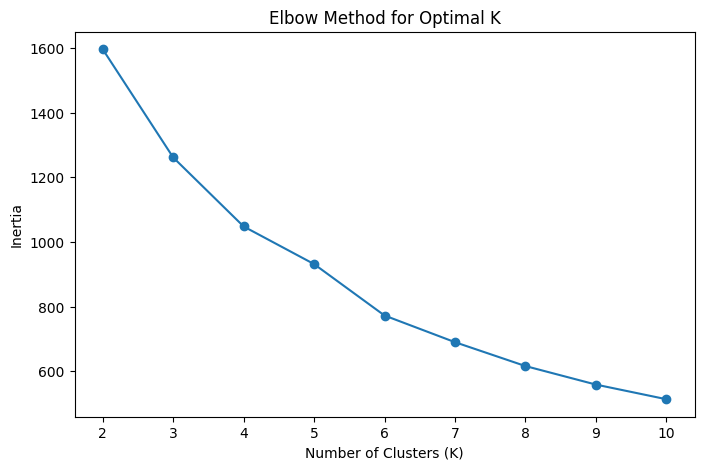

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    list(K_range),
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.title('Elbow Method for Optimal K')

plt.show()

In [50]:
silhouette_scores = []

K_range = range(2,11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)


print(silhouette_scores)

[np.float64(0.3233325883434481), np.float64(0.3444501683312919), np.float64(0.2710293546198278), np.float64(0.24250598377114982), np.float64(0.24893155337289843), np.float64(0.25696005455525944), np.float64(0.2584298329048955), np.float64(0.25964003008998976), np.float64(0.2566372592302551)]


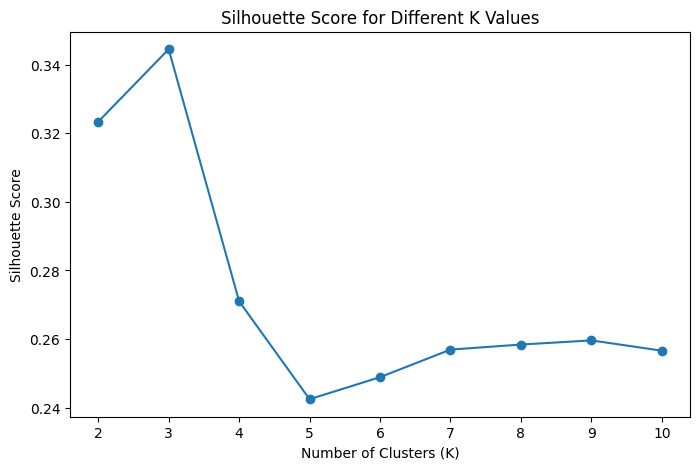

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.title('Silhouette Score for Different K Values')

plt.show()

## 10. Final K-Means Clustering

In [52]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(rfm_scaled)

In [53]:
rfm['Cluster'] = cluster_labels

rfm.head()

,customer_name,Recency,Frequency,Monetary,Cluster
0,Aaron Bergman,17,37,24646,2
1,Aaron Hawkins,13,34,20759,2
2,Aaron Smayling,24,31,14207,1
3,Adam Bellavance,36,41,20189,2
4,Adam Hart,3,42,21720,2


In [54]:
rfm['Cluster'].value_counts()

,count
Cluster,
1,425
2,325
0,45


In [55]:
final_kmeans.cluster_centers_

array([[ 2.7922147 , -0.50050911, -0.34439332],
       [-0.10276741, -0.5818314 , -0.58776977],
       [-0.2522262 ,  0.8301577 ,  0.81630724]])

In [56]:
cluster_profile = rfm.groupby('Cluster')[
    ['Recency','Frequency','Monetary']
].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,100.933333,29.688889,14109.933333
1,21.550588,29.249412,12842.788235
2,17.452308,36.880000,20153.147692


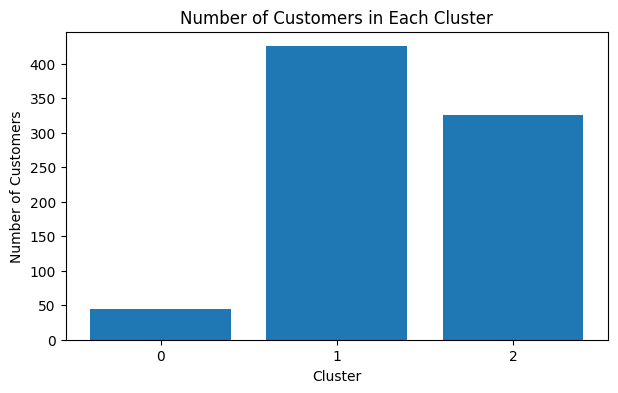

In [57]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7,4))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

In [58]:
rfm.head()

,customer_name,Recency,Frequency,Monetary,Cluster
0,Aaron Bergman,17,37,24646,2
1,Aaron Hawkins,13,34,20759,2
2,Aaron Smayling,24,31,14207,1
3,Adam Bellavance,36,41,20189,2
4,Adam Hart,3,42,21720,2


In [59]:
cluster_profile = rfm.groupby('Cluster')[
    ['Recency','Frequency','Monetary']
].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,100.933333,29.688889,14109.933333
1,21.550588,29.249412,12842.788235
2,17.452308,36.880000,20153.147692


In [60]:
from sklearn.decomposition import PCA

In [61]:
pca = PCA(
    n_components=2
)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm_pca[:5]

array([[ 1.76480785,  0.42006058],
       [ 0.95330526, -0.04622223],
       [-0.38197719, -0.15937036],
       [ 1.46356596,  0.93634881],
       [ 2.19614733, -0.06388895]])

In [62]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=['PCA1','PCA2']
)

pca_df['Cluster'] = rfm['Cluster']

pca_df.head()

,PCA1,PCA2,Cluster
0,1.764808,0.420061,2
1,0.953305,-0.046222,2
2,-0.381977,-0.159370,1
3,1.463566,0.936349,2
4,2.196147,-0.063889,2


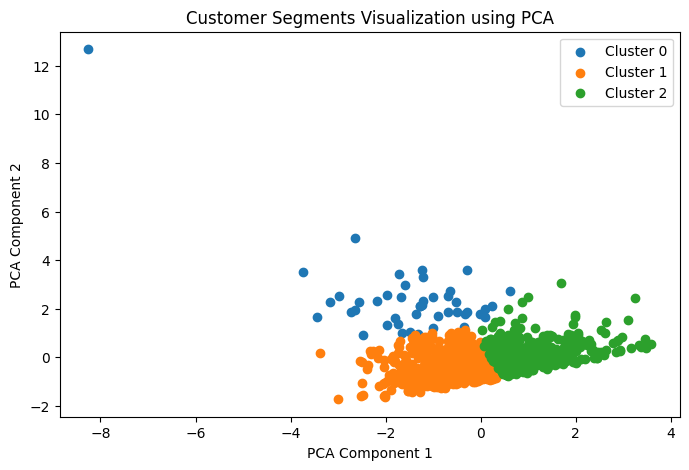

In [63]:
plt.figure(figsize=(8,5))

for cluster in sorted(pca_df['Cluster'].unique()):

    cluster_data = pca_df[
        pca_df['Cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['PCA1'],
        cluster_data['PCA2'],
        label=f'Cluster {cluster}'
    )


plt.title('Customer Segments Visualization using PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.legend()

plt.show()

In [64]:
cluster_names = {
    0: 'At-Risk Customers',
    1: 'Regular Customers',
    2: 'High Value Active Customers'
}


rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,customer_name,Recency,Frequency,Monetary,Cluster,Segment
0,Aaron Bergman,17,37,24646,2,High Value Active Customers
1,Aaron Hawkins,13,34,20759,2,High Value Active Customers
2,Aaron Smayling,24,31,14207,1,Regular Customers
3,Adam Bellavance,36,41,20189,2,High Value Active Customers
4,Adam Hart,3,42,21720,2,High Value Active Customers


In [65]:
segment_summary = rfm.groupby('Segment')[
    ['Recency','Frequency','Monetary']
].mean()

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,100.933333,29.688889,14109.933333
High Value Active Customers,17.452308,36.880000,20153.147692
Regular Customers,21.550588,29.249412,12842.788235


In [66]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print("Final Silhouette Score:", final_silhouette)

Final Silhouette Score: 0.3444501683312919


In [67]:
cluster_size = (
    rfm['Segment']
    .value_counts()
    .reset_index()
)

cluster_size.columns = [
    'Segment',
    'Number of Customers'
]

cluster_size

,Segment,Number of Customers
0,Regular Customers,425
1,High Value Active Customers,325
2,At-Risk Customers,45


In [68]:
final_summary = (
    rfm.groupby('Segment')
    [['Recency','Frequency','Monetary']]
    .mean()
    .round(2)
)

final_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,100.93,29.69,14109.93
High Value Active Customers,17.45,36.88,20153.15
Regular Customers,21.55,29.25,12842.79


In [69]:
rfm.to_csv(
    "customer_segments_result.csv",
    index=False
)

In [70]:
print("Number of clusters:", final_kmeans.n_clusters)
print("Random state:", 42)
print("Silhouette Score:", round(final_silhouette,3))

Number of clusters: 3
Random state: 42
Silhouette Score: 0.344
